In [1]:
%cd ..

/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/analysis


In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced.csv")
print(df_meta.shape)
y = df_meta["energy_above_hull"].values  # Dein Target-Vektor
print('Y shape: ', y.shape)

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_soap_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(8000, 10)
Y shape:  (8000,)
(8000, 48870)
Number of entries:  8000


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [28]:
# Direkt splitten und trainieren!
from sklearn.preprocessing import MinMaxScaler
scaler_y = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
print("Y_train Form:", y_train_scaled.shape)

y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

X_train Form: (6400, 48870)
Y_train Form: (6400,)


In [38]:
# Berechne die Perzentile
quantiles = [0.50, 0.75, 0.90, 0.95, 0.99]
percentile_values = df_meta["energy_above_hull"].quantile(quantiles)

print("Quantitative Verteilung der Energy above Hull:")
print("-----------------------------------------------")
for q, val in zip(quantiles, percentile_values):
    print(f"{int(q*100):>5}% der Daten liegen unter: {val:.4f}")

skewness = df_meta["energy_above_hull"].skew()
print(f"\nSkewness (Schiefe): {skewness:.2f}")

Quantitative Verteilung der Energy above Hull:
-----------------------------------------------
   50% der Daten liegen unter: 0.2567
   75% der Daten liegen unter: 0.6293
   90% der Daten liegen unter: 1.3095
   95% der Daten liegen unter: 1.7571
   99% der Daten liegen unter: 2.7465

Skewness (Schiefe): 2.12


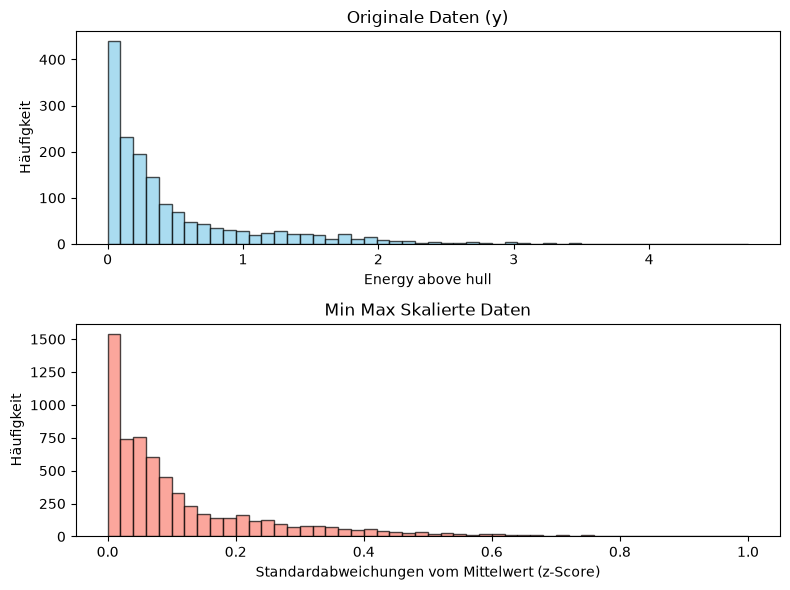

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=False)

# Oberer Plot: Originale Daten
axs[0].hist(y_test, bins=50, color="skyblue", edgecolor="black", alpha=0.7)
axs[0].set_title("Originale Daten (y)")
axs[0].set_xlabel("Energy above hull")
axs[0].set_ylabel("Häufigkeit")

# Unterer Plot: Skalierte Daten
axs[1].hist(y_train_scaled, bins=50, color="salmon", edgecolor="black", alpha=0.7)
axs[1].set_title("Min Max Skalierte Daten")
axs[1].set_xlabel("Standardabweichungen vom Mittelwert (z-Score)")
axs[1].set_ylabel("Häufigkeit")

# Layout optimieren und anzeigen
plt.tight_layout()
plt.show()

In [56]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor  # <--- GEÄNDERT: Regressor statt Classifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # <--- NEUE METRIKEN

# 1. Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=150,  # Anzahl der Bäume im Wald
    max_depth=10,
    min_samples_split=5,      # Maximale Tiefe pro Baum
    # class_weight gibt es hier nicht mehr, da wir keine Klassen haben!
    random_state=42,   # Macht die Ergebnisse reproduzierbar
    n_jobs=-1          # Nutzen aller CPU-Kerne für blitzschnelles paralleles Training
)

# 2. Train (Fit) the model
print("Trainiere Random Forest Regressor (das kann bei vielen Spalten etwas dauern)...")
rf_model.fit(X_train, y_train_scaled)
print("Training abgeschlossen!")

# 3. Make Predictions on the test data
y_pred = rf_model.predict(X_test)

# 4. Evaluate the Model (Angepasst für Regression)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Modell-Bewertung:")
print(f"----------------")
print(f"Mean Absolute Error (MAE): {mae:.2f} (Durchschnittliche Abweichung)")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} (Bestraft größere Fehler stärker)")
print(f"R² Score: {r2:.2f} (Anteil der erklärten Varianz, optimal ist 1.0)")

Trainiere Random Forest Regressor (das kann bei vielen Spalten etwas dauern)...
Training abgeschlossen!
Modell-Bewertung:
----------------
Mean Absolute Error (MAE): 0.39 (Durchschnittliche Abweichung)
Root Mean Squared Error (RMSE): 0.64 (Bestraft größere Fehler stärker)
R² Score: -0.07 (Anteil der erklärten Varianz, optimal ist 1.0)


In [65]:
import numpy as np
from sklearn.metrics import max_error, mean_absolute_error, mean_squared_error, r2_score

def evaluate_model_performance(model, title=None):
    # 1. Vorhersagen auf dem Testset generieren (liefert skalierte Werte)
    y_pred_scaled = model.predict(X_test)

    # 2. RÜCKTRANSPORT: Vorhersagen zurück in die Original-Maßeinheit bringen
    y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Hinweis: y_test liegt bereits in der Original-Maßeinheit vor (laut deinem vorherigen Code)

    # 3. Metriken berechnen
    mae = mean_absolute_error(y_test, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_original))
    r2 = r2_score(y_test, y_pred_original)
    max_err = max_error(y_test, y_pred_original)

    # 4. Schöne Ausgabe formatieren
    print("==================================================")
    print("   MODELL-PERFORMANCE AUF DEM TESTSET (ORIGINAL)")
    print("==================================================")
    print(f"Mean Absolute Error (MAE):      {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE):  {rmse:.4f}")
    print(f"R² Score (Bestimmtheitsmaß):    {r2:.4f}")
    print(f"Maximaler Fehler (Max Error):   {max_err:.4f}")
    print("==================================================")


    fig = plt.figure(figsize=(5,5))
                 
    plt.scatter(y_test_scaled,y_pred_scaled)
    plt.xlim(-0.02,1)
    plt.xlabel("True Values (Scaled)")
    plt.ylim(-0.02,1)
    plt.ylabel("Predictions (Scaled)")
    plt.title(title)

    x = np.linspace(0,1,100)
    plt.plot(x,x, color='red', linestyle='--', label='y=x')

   MODELL-PERFORMANCE AUF DEM TESTSET (ORIGINAL)
Mean Absolute Error (MAE):      0.1880
Root Mean Squared Error (RMSE):  0.2831
R² Score (Bestimmtheitsmaß):    0.7910
Maximaler Fehler (Max Error):   1.7147


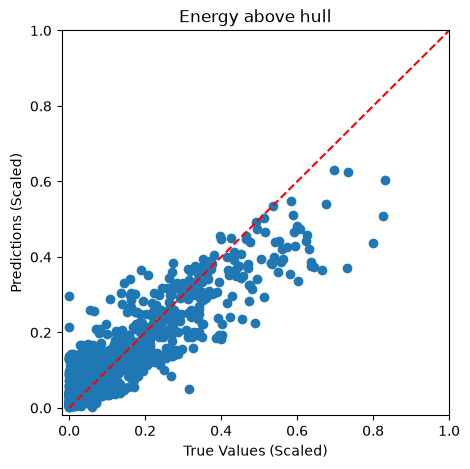

In [68]:
evaluate_model_performance(rf_model, title="Energy above hull")

In [40]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren (ohne class_weight, da Regression)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. Den Suchraum (Grid) festlegen
param_grid = {
    "n_estimators": [50, 100],  # Anzahl der Bäume
    "max_depth": [5, 10, None],  # Tiefe der Bäume (None bedeutet unbegrenzt)
    "min_samples_split": [2, 5],  # Mindestanzahl an Datenpunkten für einen Split
}

# 3. Grid Search initialisieren
# scoring='neg_mean_squared_error' optimiert auf den geringsten quadratischen Fehler.
# Alternativ könntest du auch 'r2' nutzen.
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  # 3-fache Kreuzvalidierung
    scoring="neg_mean_squared_error",  # <--- GEÄNDERT: Regressions-Metrik
    verbose=2,  # Zeigt den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
)

# 4. Suche starten
print("Starte Grid Search für Regression...")
grid_search.fit(X_train, y_train_scaled)

# 5. Bestes Ergebnis anzeigen
print("\n=== GRID SEARCH BEENDET ===")
# Wir nehmen das Negative des Scores und ziehen die Wurzel, um den echten RMSE anzuzeigen
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Bester RMSE-Score (ca. Abweichung): {best_rmse:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search.best_params_)

# Das beste Modell direkt für Vorhersagen nutzen
best_rf_regressor = grid_search.best_estimator_

Starte Grid Search für Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time= 4.0min
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time= 4.0min
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time= 4.0min
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time= 4.0min
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time= 4.0min
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time= 7.5min
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time= 7.5min
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time= 7.5min
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time= 4.1min
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time= 6.0min
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time= 7.5min
[CV] END .m

   MODELL-PERFORMANCE AUF DEM TESTSET (ORIGINAL)
Mean Absolute Error (MAE):      0.1229
Root Mean Squared Error (RMSE):  0.2487
R² Score (Bestimmtheitsmaß):    0.8396
Maximaler Fehler (Max Error):   4.5385


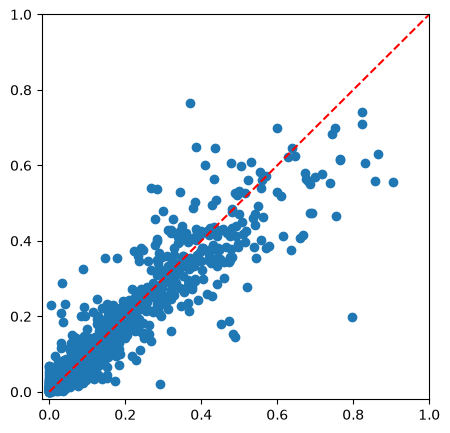

In [55]:
evaluate_model_performance(best_rf_regressor)

Gute Gesamtabdeckung (R 
2
 =0.84): Das Modell ist stark. Es kann rund 84 % der Varianz der Energy above Hull auf komplett unbekannten Testdaten korrekt erklären. Für ein komplexes physikalisches Regressionsmodell ist das ein sehr solider Wert.
Präzise Vorhersage im Alltag (MAE = 0.12): Im Durchschnitt weichen die Vorhersagen des Modells nur um 0.12 Einheiten vom tatsächlichen Wert ab. Das zeigt, dass der Großteil der Strukturen sehr präzise geschätzt wird.
Einfluss von Extremwerten (RMSE vs. MAE): Der RMSE ist mit 0.25 doppelt so hoch wie der MAE. Das ist die mathematische Bestätigung für deine Beobachtung, dass vereinzelt sehr große Energiewerte im Datensatz existieren. Da der RMSE große Abweichungen quadratisch bestraft, wird er durch diese Ausreißer nach oben gezogen.
Die Schwachstelle (Max Error = 4.54): Der maximale Fehler zeigt, dass das Modell bei mindestens einer Struktur (sehr wahrscheinlich eine der vereinzelten, extrem instabilen Phasen) um 4.54 Einheiten daneben lag.

# ==========================================================

## Try Ewald Sum Matrix

In [58]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced_EwaldM.csv")
print(df_meta.shape)
y = df_meta["energy_above_hull"].values  # Dein Target-Vektor
print('Y shape: ', y.shape)

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_ewald_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(7875, 10)
Y shape:  (7875,)
(7875, 900)
Number of entries:  7875


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


In [59]:
# Direkt splitten und trainieren!
from sklearn.preprocessing import MinMaxScaler
scaler_y = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
print("Y_train Form:", y_train_scaled.shape)

y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

X_train Form: (6300, 900)
Y_train Form: (6300,)


In [61]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor  # <--- GEÄNDERT: Regressor statt Classifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # <--- NEUE METRIKEN

# 1. Initialize the Random Forest Regressor
rf_ew_model = RandomForestRegressor(
    n_estimators=150,  # Anzahl der Bäume im Wald
    max_depth=10,
    min_samples_split=5,      # Maximale Tiefe pro Baum
    # class_weight gibt es hier nicht mehr, da wir keine Klassen haben!
    random_state=42,   # Macht die Ergebnisse reproduzierbar
    n_jobs=-1          # Nutzen aller CPU-Kerne für blitzschnelles paralleles Training
)

# 2. Train (Fit) the model
print("Trainiere Random Forest Regressor (das kann bei vielen Spalten etwas dauern)...")
rf_ew_model.fit(X_train, y_train_scaled)
print("Training abgeschlossen!")

# 3. Make Predictions on the test data
y_pred = rf_ew_model.predict(X_test)

# 4. Evaluate the Model (Angepasst für Regression)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Modell-Bewertung:")
print(f"----------------")
print(f"Mean Absolute Error (MAE): {mae:.2f} (Durchschnittliche Abweichung)")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} (Bestraft größere Fehler stärker)")
print(f"R² Score: {r2:.2f} (Anteil der erklärten Varianz, optimal ist 1.0)")

Trainiere Random Forest Regressor (das kann bei vielen Spalten etwas dauern)...
Training abgeschlossen!
Modell-Bewertung:
----------------
Mean Absolute Error (MAE): 0.39 (Durchschnittliche Abweichung)
Root Mean Squared Error (RMSE): 0.65 (Bestraft größere Fehler stärker)
R² Score: -0.11 (Anteil der erklärten Varianz, optimal ist 1.0)


   MODELL-PERFORMANCE AUF DEM TESTSET (ORIGINAL)
Mean Absolute Error (MAE):      0.1880
Root Mean Squared Error (RMSE):  0.2831
R² Score (Bestimmtheitsmaß):    0.7910
Maximaler Fehler (Max Error):   1.7147


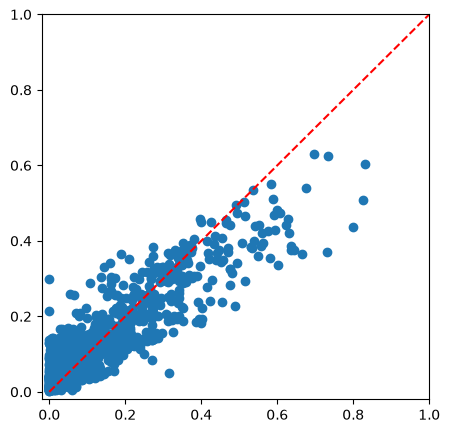

In [62]:
evaluate_model_performance(rf_ew_model)

## Grid search with Ewald Matrices

In [70]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren (ohne class_weight, da Regression)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. Den Suchraum (Grid) festlegen
param_grid = {
    "n_estimators": [50, 100, 200],  # Anzahl der Bäume
    "max_depth": [5, 10, None],  # Tiefe der Bäume (None bedeutet unbegrenzt)
    "min_samples_split": [4, 6, 8],  # Mindestanzahl an Datenpunkten für einen Split
}

# 3. Grid Search initialisieren
# scoring='neg_mean_squared_error' optimiert auf den geringsten quadratischen Fehler.
# Alternativ könntest du auch 'r2' nutzen.
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  # 3-fache Kreuzvalidierung
    scoring="neg_mean_squared_error",  # <--- GEÄNDERT: Regressions-Metrik
    verbose=2,  # Zeigt den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
)

# 4. Suche starten
print("Starte Grid Search für Regression...")
grid_search.fit(X_train, y_train_scaled)

# 5. Bestes Ergebnis anzeigen
print("\n=== GRID SEARCH BEENDET ===")
# Wir nehmen das Negative des Scores und ziehen die Wurzel, um den echten RMSE anzuzeigen
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Bester RMSE-Score (ca. Abweichung): {best_rmse:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search.best_params_)

# Das beste Modell direkt für Vorhersagen nutzen
best_rf_ew_regressor = grid_search.best_estimator_

Starte Grid Search für Regression...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..max_depth=5, min_samples_split=4, n_estimators=50; total time=   6.5s
[CV] END ..max_depth=5, min_samples_split=4, n_estimators=50; total time=   7.0s
[CV] END ..max_depth=5, min_samples_split=4, n_estimators=50; total time=   7.0s
[CV] END .max_depth=5, min_samples_split=4, n_estimators=100; total time=  13.2s
[CV] END .max_depth=5, min_samples_split=4, n_estimators=100; total time=  13.4s
[CV] END .max_depth=5, min_samples_split=4, n_estimators=100; total time=  13.4s
[CV] END ..max_depth=5, min_samples_split=6, n_estimators=50; total time=   7.1s
[CV] END ..max_depth=5, min_samples_split=6, n_estimators=50; total time=   7.2s
[CV] END ..max_depth=5, min_samples_split=6, n_estimators=50; total time=   7.0s
[CV] END .max_depth=5, min_samples_split=4, n_estimators=200; total time=  27.0s
[CV] END .max_depth=5, min_samples_split=4, n_estimators=200; total time=  26.5s
[CV] END .m

   MODELL-PERFORMANCE AUF DEM TESTSET (ORIGINAL)
Mean Absolute Error (MAE):      0.1387
Root Mean Squared Error (RMSE):  0.2164
R² Score (Bestimmtheitsmaß):    0.8778
Maximaler Fehler (Max Error):   1.4458


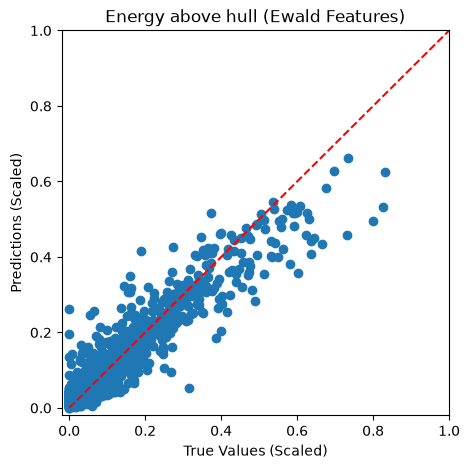

In [69]:
evaluate_model_performance(best_rf_ew_regressor, title="Energy above hull (Ewald Features)")